# EDA - Walmart Store Sales Forecasting

Loads `train.csv`, `test.csv`, `features.csv`, `stores.csv`, checks shapes/missingness against the expected dataset sizes, looks at the holiday weighting (WMAE) angle, and the Store Type / Size relationship.

In [14]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path.cwd().parent))
from src.evaluation import weighted_mae

DATA_DIR = Path.cwd().parent / "data" / "raw"
pd.set_option("display.max_columns", None)

In [15]:
# Kaggle zip artifacts: train.csv/test.csv/features.csv are directories containing a same-named .csv file
train = pd.read_csv(DATA_DIR / "train.csv" / "train.csv", parse_dates=["Date"])
test = pd.read_csv(DATA_DIR / "test.csv" / "test.csv", parse_dates=["Date"])
features = pd.read_csv(DATA_DIR / "features.csv" / "features.csv", parse_dates=["Date"])
stores = pd.read_csv(DATA_DIR / "stores.csv")

print("train:", train.shape)
print("test:", test.shape)
print("features:", features.shape)
print("stores:", stores.shape)

train: (421570, 5)
test: (115064, 4)
features: (8190, 12)
stores: (45, 3)


In [16]:
train.dtypes

Store                    int64
Dept                     int64
Date            datetime64[us]
Weekly_Sales           float64
IsHoliday                 bool
dtype: object

In [17]:
features.isna().mean().sort_values(ascending=False)

MarkDown2       0.643346
MarkDown4       0.577045
MarkDown3       0.558852
MarkDown1       0.507692
MarkDown5       0.505495
CPI             0.071429
Unemployment    0.071429
Store           0.000000
Fuel_Price      0.000000
Temperature     0.000000
Date            0.000000
IsHoliday       0.000000
dtype: float64

### MarkDown availability

Check the earliest date with any non-null MarkDown value.

In [18]:
markdown_cols = [c for c in features.columns if c.startswith("MarkDown")]
has_any_markdown = features[markdown_cols].notna().any(axis=1)
print("Earliest date with any MarkDown value:", features.loc[has_any_markdown, "Date"].min())
print("mean of rows with at least one MarkDown value:", has_any_markdown.mean())

Earliest date with any MarkDown value: 2011-11-11 00:00:00
mean of rows with at least one MarkDown value: 0.4945054945054945


### Weekly_Sales distribution - check for zero/negative values

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

rows with Weekly_Sales <= 0: 1358 (0.322%)


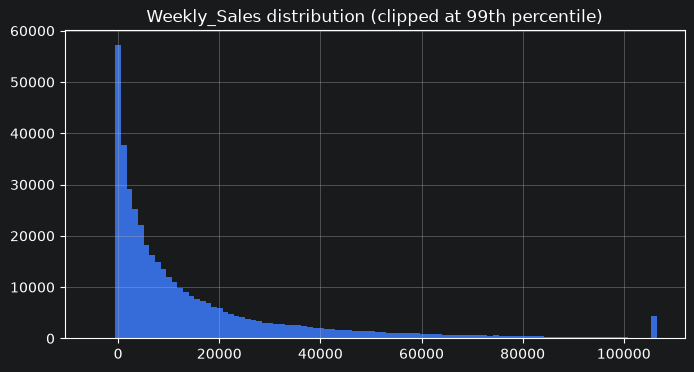

In [19]:
print(train["Weekly_Sales"].describe())
print("\nrows with Weekly_Sales <= 0:", (train["Weekly_Sales"] <= 0).sum(),
      f"({(train['Weekly_Sales'] <= 0).mean():.3%})")

fig, ax = plt.subplots(figsize=(8, 4))
train["Weekly_Sales"].clip(upper=train["Weekly_Sales"].quantile(0.99)).hist(bins=100, ax=ax)
ax.set_title("Weekly_Sales distribution (clipped at 99th percentile)")
plt.show()

### Holiday vs non-holiday sales

This is the WMAE-relevant cut: holiday weeks get 5x the error weight in the competition metric, so it's worth seeing how different their sales distribution actually is.

In [20]:
train.groupby("IsHoliday")["Weekly_Sales"].agg(["mean", "median", "std", "count"])

,mean,median,std,count
IsHoliday,,,,
False,15901.445069,7589.95,22330.747450,391909
True,17035.823187,7947.74,27222.000409,29661


### The four Walmart holidays, by year

Note: the dataset marks the last week of the year as the Christmas holiday.
Check whether the actual sales peak aligns with this or falls in the prior week.

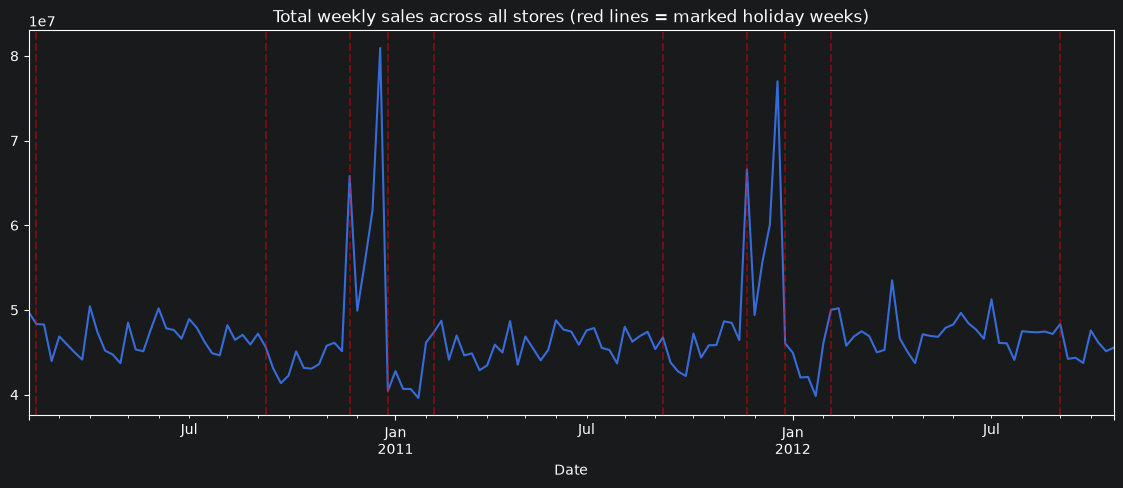

In [21]:
holidays = {
    "Super Bowl": ["2010-02-12", "2011-02-11", "2012-02-10"],
    "Labor Day": ["2010-09-10", "2011-09-09", "2012-09-07"],
    "Thanksgiving": ["2010-11-26", "2011-11-25", "2012-11-23"],
    "Christmas": ["2010-12-31", "2011-12-30", "2012-12-28"],
}

weekly_total = train.groupby("Date")["Weekly_Sales"].sum()

fig, ax = plt.subplots(figsize=(14, 5))
weekly_total.plot(ax=ax)
for name, dates in holidays.items():
    for d in dates:
        ax.axvline(pd.Timestamp(d), color="red", linestyle="--", alpha=0.4)
ax.set_title("Total weekly sales across all stores (red lines = marked holiday weeks)")
plt.show()

In [22]:
# Zoom into late-Dec each year to see the week-51 pre-Christmas peak vs the marked holiday week
for year in [2010, 2011]:
    window = weekly_total[(weekly_total.index >= f"{year}-12-01") & (weekly_total.index <= f"{year}-12-31")]
    print(f"\n{year} late-Dec weekly totals:")
    print(window)


2010 late-Dec weekly totals:
Date
2010-12-03    49909027.88
2010-12-10    55666770.39
2010-12-17    61820799.85
2010-12-24    80931415.60
2010-12-31    40432519.00
Name: Weekly_Sales, dtype: float64

2011 late-Dec weekly totals:
Date
2011-12-02    49390556.49
2011-12-09    55561147.70
2011-12-16    60085695.94
2011-12-23    76998241.31
2011-12-30    46042461.04
Name: Weekly_Sales, dtype: float64


### Sales by Store Type and Size
Check correlation between size and sales

In [23]:
train_stores = train.merge(stores, on="Store", how="left")

print(stores.groupby("Type")["Size"].agg(["mean", "min", "max", "count"]))
print()
print(train_stores.groupby("Type")["Weekly_Sales"].agg(["mean", "median", "sum"]))

               mean    min     max  count
Type                                     
A     177247.727273  39690  219622     22
B     101190.705882  34875  140167     17
C      40541.666667  39690   42988      6

              mean    median           sum
Type                                      
A     20099.568043  10105.17  4.331015e+09
B     12237.075977   6187.87  2.000701e+09
C      9519.532538   1149.67  4.055035e+08


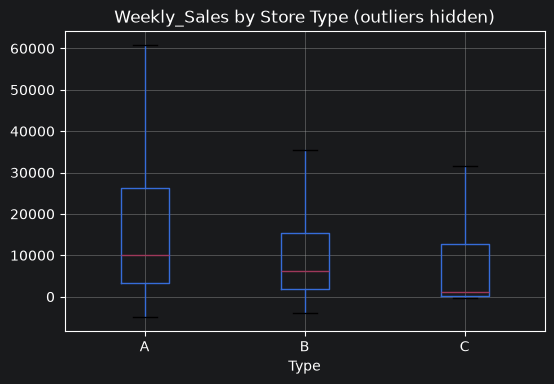

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))
train_stores.boxplot(column="Weekly_Sales", by="Type", ax=ax, showfliers=False)
ax.set_title("Weekly_Sales by Store Type (outliers hidden)")
plt.suptitle("")
plt.show()

### Sanity-check: `src/evaluation.py` import works from a notebook

In [25]:
toy_true = np.array([100.0, 100.0])
toy_pred = np.array([90.0, 100.0])
toy_holiday = np.array([True, False])
score = weighted_mae(toy_true, toy_pred, toy_holiday)
print("weighted_mae sanity check:", score)
assert np.isclose(score, 8.3333333), "WMAE sanity check failed"

weighted_mae sanity check: 8.333333333333334


## Findings summary

- Row counts verified for `train`, `features`, and `stores`.
- MarkDown1-5 are almost entirely null before the 2011-11-11 - any model using them needs a strategy for the pre-2011 gap (fill with 0 or exclude from early-period training rows).
- A small fraction of `Weekly_Sales` rows are zero or negative (returns/inactive departments) – worth deciding whether to clip, drop, or keep these per-model.
- Holiday weeks show a visibly different sales distribution than non-holiday weeks, consistent with the 5× WMAE weighting.
- The total-sales time series shows the real shopping peak landing a week before the marked Christmas holiday week; feature engineering should treat week 51 as holiday-adjacent.
- Store Type A has the largest average `Size` and the highest average `Weekly_Sales`, suggesting Type A = largest/highest-volume stores.